In [2]:
import os
import sys
import pandas as pd
import numpy as np

# Add the project root to Python's path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.load_data import load_data

df = load_data()

print(df.shape)

(1067371, 8)


In [3]:
import os
import sys

# Add the project root to Python's path
project_root = os.path.abspath("..")
if project_root not in sys.path:
    sys.path.insert(0, project_root)

from src.load_data import load_data

df = load_data()

print(df.shape)
df.head()

(1067371, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [4]:
# Find the last transaction date in the dataset
snapshot_date = df["InvoiceDate"].max()

print("Last transaction date:", snapshot_date)

# Customer's last purchase date
last_purchase = (
    df.groupby("Customer ID")["InvoiceDate"]
      .max()
      .reset_index()
)

# Calculate Recency (days since last purchase)
last_purchase["Recency"] = (
    snapshot_date - last_purchase["InvoiceDate"]
).dt.days

# Create Churn column
last_purchase["Churn"] = (
    last_purchase["Recency"] > 90
).astype(int)

# Display first few rows
last_purchase.head()

Last transaction date: 2011-12-09 12:50:00


,Customer ID,InvoiceDate,Recency,Churn
0,12346.0,2011-01-18 10:17:00,325,1
1,12347.0,2011-12-07 15:52:00,1,0
2,12348.0,2011-09-25 13:13:00,74,0
3,12349.0,2011-11-21 09:51:00,18,0
4,12350.0,2011-02-02 16:01:00,309,1


In [5]:
import os

print(os.getcwd())

c:\Users\ADMIN\OneDrive\Documents\GitHub\Customer-behavior-prediction\notebooks


In [6]:
# Load customer-level features
customer_features = pd.read_csv("../data/processed/customer_features.csv")

# Merge with churn labels
model_data = customer_features.merge(
    last_purchase[["Customer ID", "Churn"]],
    on="Customer ID",
    how="left"
)

# Check the result
print(model_data.shape)
model_data.head()

(5942, 13)


,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder,Churn
0,12346.0,-64.68,17,52,-1.347500,2009-12-14 08:34:00,2011-01-18 10:17:00,400,13.333333,1.275000,-1.243846,3.058824,1
1,12347.0,5633.32,8,3286,22.266087,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.400000,0.597015,1.714340,410.750000,0
2,12348.0,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.066667,0.414365,0.744068,542.800000,0
3,12349.0,4404.54,5,1619,24.469667,2009-12-04 12:49:00,2011-11-21 09:51:00,716,23.866667,0.209497,2.720531,323.800000,0
4,12350.0,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000,1.000000,1.697462,197.000000,1


In [7]:
customer_features = pd.read_csv("../data/processed/customer_features.csv")

print(customer_features.shape)
customer_features.head()

(5942, 12)


,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder
0,12346.0,-64.68,17,52,-1.347500,2009-12-14 08:34:00,2011-01-18 10:17:00,400,13.333333,1.275000,-1.243846,3.058824
1,12347.0,5633.32,8,3286,22.266087,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.400000,0.597015,1.714340,410.750000
2,12348.0,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.066667,0.414365,0.744068,542.800000
3,12349.0,4404.54,5,1619,24.469667,2009-12-04 12:49:00,2011-11-21 09:51:00,716,23.866667,0.209497,2.720531,323.800000
4,12350.0,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000,1.000000,1.697462,197.000000


In [8]:
# Merge customer features with churn labels
model_data = customer_features.merge(
    last_purchase[["Customer ID", "Churn"]],
    on="Customer ID",
    how="left"
)

# Check the merged dataset
print(model_data.shape)
model_data.head()

(5942, 13)


,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder,Churn
0,12346.0,-64.68,17,52,-1.347500,2009-12-14 08:34:00,2011-01-18 10:17:00,400,13.333333,1.275000,-1.243846,3.058824,1
1,12347.0,5633.32,8,3286,22.266087,2010-10-31 14:20:00,2011-12-07 15:52:00,402,13.400000,0.597015,1.714340,410.750000,0
2,12348.0,2019.40,5,2714,39.596078,2010-09-27 14:59:00,2011-09-25 13:13:00,362,12.066667,0.414365,0.744068,542.800000,0
3,12349.0,4404.54,5,1619,24.469667,2009-12-04 12:49:00,2011-11-21 09:51:00,716,23.866667,0.209497,2.720531,323.800000,0
4,12350.0,334.40,1,197,19.670588,2011-02-02 16:01:00,2011-02-02 16:01:00,0,1.000000,1.000000,1.697462,197.000000,1


In [10]:
# Check class balance
print(model_data["Churn"].value_counts())

print("\nPercentage:")

print(model_data["Churn"].value_counts(normalize=True) * 100)

Churn
1    3020
0    2922
Name: count, dtype: int64

Percentage:
Churn
1    50.824638
0    49.175362
Name: proportion, dtype: float64


In [33]:
from sklearn.model_selection import train_test_split

# Features (X)
X = model_data.drop(columns=[
    "Customer ID",
    "Churn",
    "FirstPurchase",
    "LastPurchase"
])

# Target (y)
y = model_data["Churn"]

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

Training set: (4753, 9)
Testing set : (1189, 9)


In [34]:
from sklearn.linear_model import LogisticRegression

# Create the model
log_model = LogisticRegression(max_iter=1000)

# Train the model
log_model.fit(X_train, y_train)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


c:\Users\ADMIN\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [36]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = log_model.predict(X_test)
y_prob = log_model.predict_proba(X_test)[:, 1]

# Evaluation Metrics
print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

Accuracy : 0.7157275021026073
Precision: 0.6985074626865672
Recall   : 0.7748344370860927
F1 Score : 0.7346938775510204
ROC-AUC  : 0.7787909662081848

Confusion Matrix
[[383 202]
 [136 468]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.65      0.69       585
           1       0.70      0.77      0.73       604

    accuracy                           0.72      1189
   macro avg       0.72      0.71      0.71      1189
weighted avg       0.72      0.72      0.71      1189



In [37]:
from sklearn.tree import DecisionTreeClassifier

In [38]:
# Create the model
dt_model = DecisionTreeClassifier(random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [39]:
# Make predictions
y_pred_dt = dt_model.predict(X_test)

# Predict probabilities (needed for ROC-AUC)
y_prob_dt = dt_model.predict_proba(X_test)[:, 1]

# Evaluation metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)

print("Accuracy :", accuracy_score(y_test, y_pred_dt))
print("Precision:", precision_score(y_test, y_pred_dt))
print("Recall   :", recall_score(y_test, y_pred_dt))
print("F1 Score :", f1_score(y_test, y_pred_dt))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_dt))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_dt))

print("\nClassification Report")
print(classification_report(y_test, y_pred_dt))

Accuracy : 0.6551724137931034
Precision: 0.6616666666666666
Recall   : 0.6572847682119205
F1 Score : 0.659468438538206
ROC-AUC  : 0.6551381106016867

Confusion Matrix
[[382 203]
 [207 397]]

Classification Report
              precision    recall  f1-score   support

           0       0.65      0.65      0.65       585
           1       0.66      0.66      0.66       604

    accuracy                           0.66      1189
   macro avg       0.66      0.66      0.66      1189
weighted avg       0.66      0.66      0.66      1189



In [40]:
from sklearn.ensemble import RandomForestClassifier

In [41]:
# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [42]:
# Make predictions
y_pred_rf = rf_model.predict(X_test)

# Predict probabilities
y_prob_rf = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.7174095878889823
Precision: 0.703030303030303
Recall   : 0.7682119205298014
F1 Score : 0.7341772151898734
ROC-AUC  : 0.7884926699496236

Confusion Matrix
[[389 196]
 [140 464]]

Classification Report
              precision    recall  f1-score   support

           0       0.74      0.66      0.70       585
           1       0.70      0.77      0.73       604

    accuracy                           0.72      1189
   macro avg       0.72      0.72      0.72      1189
weighted avg       0.72      0.72      0.72      1189



In [52]:
# Model Comparison Table

import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.6871,
        0.6005,
        0.6712
    ],
    "Precision": [
        0.6461,
        0.6088,
        0.6790
    ],
    "Recall": [
        0.8493,
        0.5977,
        0.6689
    ],
    "F1 Score": [
        0.7339,
        0.6032,
        0.6739
    ],
    "ROC-AUC": [
        0.7616,
        0.6016,
        0.7379
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6871,0.6461,0.8493,0.7339,0.7616
1,Decision Tree,0.6005,0.6088,0.5977,0.6032,0.6016
2,Random Forest,0.6712,0.6790,0.6689,0.6739,0.7379


In [1]:
import pandas as pd

comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        0.7157,
        0.6552,
        0.7174
    ],
    "Precision": [
        0.6985,
        0.6617,
        0.7030
    ],
    "Recall": [
        0.7748,
        0.6573,
        0.7682
    ],
    "F1 Score": [
        0.7347,
        0.6595,
        0.7342
    ],
    "ROC-AUC": [
        0.7788,
        0.6551,
        0.7885
    ]
})

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.7157,0.6985,0.7748,0.7347,0.7788
1,Decision Tree,0.6552,0.6617,0.6573,0.6595,0.6551
2,Random Forest,0.7174,0.7030,0.7682,0.7342,0.7885


In [53]:
comparison.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison table saved successfully!")

Model comparison table saved successfully!


In [2]:
comparison_df.to_csv(
    "../data/processed/model_comparison.csv",
    index=False
)

print("Model comparison saved successfully!")

Model comparison saved successfully!


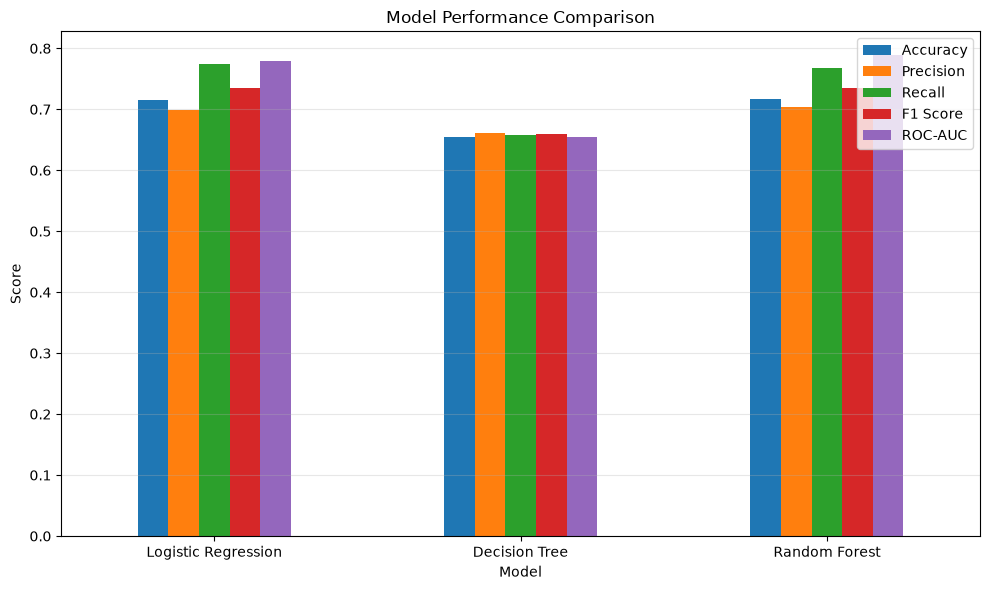

In [3]:
import matplotlib.pyplot as plt

comparison_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    kind="bar",
    figsize=(10,6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

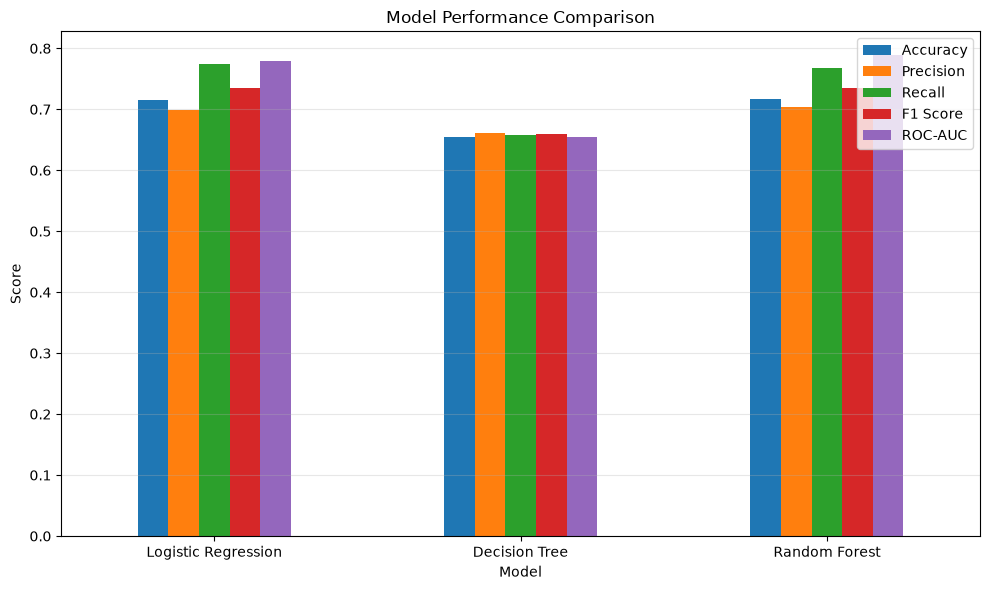

Chart saved successfully!


In [4]:
import os
import matplotlib.pyplot as plt

# Create reports folder if it doesn't exist
os.makedirs("../reports", exist_ok=True)

# Plot again
comparison_df.plot(
    x="Model",
    y=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"],
    kind="bar",
    figsize=(10, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)

plt.tight_layout()

# Save chart
plt.savefig("../reports/model_performance_comparison.png", dpi=300)

plt.show()

print("Chart saved successfully!")

In [14]:
# Check missing values in model_data
print(model_data.isnull().sum())

Customer ID                   0
TotalSpend                    0
TotalOrders                   0
TotalProducts                 0
AverageOrderValue             0
FirstPurchase                 0
LastPurchase                  0
CustomerTenure                0
TenureMonths                  0
PurchaseFrequencyPerMonth     0
AverageSpendPerProduct       10
AverageQuantityPerOrder       0
Churn                         0
dtype: int64


In [25]:
# Replace missing values with 0
model_data["AverageSpendPerProduct"] = (
    model_data["AverageSpendPerProduct"]
    .fillna(0)
)

# Verify
print(model_data.isnull().sum())

Customer ID                  0
TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
FirstPurchase                0
LastPurchase                 0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
Churn                        0
dtype: int64


In [23]:
print(X_train.isnull().sum())

TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
dtype: int64


In [24]:
print(X_train.isnull().sum().sum())

0


In [22]:
import numpy as np

print(np.isinf(X_train).sum())
print(np.isinf(X_train).sum().sum())

TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       8
AverageQuantityPerOrder      0
dtype: int64
8


In [28]:
print(X_train.shape)
print(X_train.isnull().sum().sum())

(4753, 9)
0


In [29]:
import numpy as np

# Check infinity values in every column
print(np.isinf(X_train).sum())

# Total number of infinity values
print(np.isinf(X_train).sum().sum())

TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       8
AverageQuantityPerOrder      0
dtype: int64
8


In [30]:
# Replace infinity values with 0
X_train = X_train.replace([np.inf, -np.inf], 0)
X_test = X_test.replace([np.inf, -np.inf], 0)

# Verify
print(np.isinf(X_train).sum())
print(np.isinf(X_train).sum().sum())

TotalSpend                   0
TotalOrders                  0
TotalProducts                0
AverageOrderValue            0
CustomerTenure               0
TenureMonths                 0
PurchaseFrequencyPerMonth    0
AverageSpendPerProduct       0
AverageQuantityPerOrder      0
dtype: int64
0


In [31]:
model_data[model_data["AverageSpendPerProduct"].isna()]

,Customer ID,TotalSpend,TotalOrders,TotalProducts,AverageOrderValue,FirstPurchase,LastPurchase,CustomerTenure,TenureMonths,PurchaseFrequencyPerMonth,AverageSpendPerProduct,AverageQuantityPerOrder,Churn


In [32]:
import numpy as np

model_data["AverageSpendPerProduct"] = (
    model_data["AverageSpendPerProduct"]
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
)

print(model_data["AverageSpendPerProduct"].isnull().sum())
print(np.isinf(model_data["AverageSpendPerProduct"]).sum())

0
0


In [35]:
print(X_train.dtypes)

TotalSpend                   float64
TotalOrders                    int64
TotalProducts                  int64
AverageOrderValue            float64
CustomerTenure                 int64
TenureMonths                 float64
PurchaseFrequencyPerMonth    float64
AverageSpendPerProduct       float64
AverageQuantityPerOrder      float64
dtype: object
